# Projeto de Análise Exploratória e Limpeza de Dados — E-commerce Brasileiro

## Contexto

Este projeto tem como objetivo realizar uma análise exploratória (EDA) e o processo de limpeza e preparação dos dados de um conjunto público de e-commerce brasileiro, disponibilizado pela Olist.

A base contém informações sobre pedidos, clientes, produtos, pagamentos, entregas e avaliações, permitindo uma visão completa do fluxo de vendas em um marketplace.

---

## Objetivo do Projeto

O principal objetivo deste notebook é:

- Compreender a estrutura dos dados
- Identificar inconsistências, valores ausentes e possíveis outliers
- Realizar o tratamento e a padronização das informações
- Preparar uma base confiável para análises futuras e construção de indicadores

Este projeto foi desenvolvido com foco em boas práticas de análise de dados, organização e clareza do raciocínio.

---

## Etapas Desenvolvidas

Ao longo deste notebook, são abordadas as seguintes etapas:

1. Importação e inspeção inicial dos dados  
2. Análise da estrutura das tabelas  
3. Verificação de valores nulos e duplicados  
4. Tratamento de inconsistências  
5. Padronização de formatos (datas, textos e categorias)  
6. Criação de variáveis auxiliares  
7. Validação da base final

Cada etapa é documentada com comentários explicativos, destacando as decisões tomadas durante o processo.

---

## Resultado Esperado

Ao final do projeto, espera-se obter:

- Uma base de dados limpa e estruturada
- Maior entendimento do comportamento dos clientes e pedidos
- Fundamento sólido para análises descritivas, dashboards e modelos analíticos

---

## Contexto Profissional

Este projeto faz parte do meu processo de desenvolvimento como Analista de Dados, com foco na construção de um portfólio prático, baseado em dados reais e problemas próximos ao ambiente corporativo.

O objetivo é demonstrar não apenas domínio técnico, mas também organização, pensamento analítico e capacidade de comunicação dos resultados.

---


In [ ]:
# Montar drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Definir caminho dos dados e listar arquivos

import os

DATA_RAW = "/content/drive/MyDrive/olist_raw"
print("DATA_RAW:", DATA_RAW)

files = os.listdir(DATA_RAW)
print("Qtd arquivos:", len(files))
print("Primeiros 20:", files[:20])

DATA_RAW: /content/drive/MyDrive/olist_raw
Qtd arquivos: 6
Primeiros 20: ['olist_customers_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_orders_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv']


In [ ]:
# Função "read_csv_safe" (leitura "segura" de csv)

import pandas as pd
import os

def read_csv_safe(filename: str, encoding: str = "utf-8") -> pd.DataFrame:
  path = os.path.join(DATA_RAW, filename)

  if not os.path.exists(path):
    raise FileNotFoundError(
        f"Arquivo não encontrado: {path}\n"
        f"Verifique se o arquivo está no diretório correto."
    )

  try:
    df = pd.read_csv(path, encoding=encoding)
    print(f"OK: {filename} -> {df.shape[0]:,} linhas x {df.shape[1]} colunas")
    return df

  except UnicodeDecodeError:
    raise UnicodeDecodeError(
        f"Erro de encoding ao ler {filename}. "
        f"Tente especificar outro encoding (como 'latin1' ou 'ISO-8859-1')."
    )

  except pd.errors.ParserError:
    raise ValueError(
        f"Erro ao interpretar o CSV {filename}. "
        f"O arquivo pode estar corrompido ou mal formatado."
    )

  except Exception as e:
    raise RuntimeError(
        f"Erro inesperado ao ler {filename}: {str(e)}"
    )

In [ ]:
# Carregar tabelas (core)

orders = read_csv_safe("olist_orders_dataset.csv")
order_items = read_csv_safe("olist_order_items_dataset.csv")
customers = read_csv_safe("olist_customers_dataset.csv")
payments = read_csv_safe("olist_order_payments_dataset.csv")
products = read_csv_safe("olist_products_dataset.csv")

OK: olist_orders_dataset.csv -> 99,441 linhas x 8 colunas
OK: olist_order_items_dataset.csv -> 112,650 linhas x 7 colunas
OK: olist_customers_dataset.csv -> 99,441 linhas x 5 colunas
OK: olist_order_payments_dataset.csv -> 103,886 linhas x 5 colunas
OK: olist_products_dataset.csv -> 32,951 linhas x 9 colunas


In [ ]:
# Ver tamanho, colunas e primeiras linhas

print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("customers:", customers.shape)
print("payments:", payments.shape)
print("products:", products.shape)

# Visualiza primeiras linhas (amostra)
display(orders.head(3))
display(order_items.head(3))
display(customers.head(3))
display(payments.head(3))
display(products.head(3))

orders: (99441, 8)
order_items: (112650, 7)
customers: (99441, 5)
payments: (103886, 5)
products: (32951, 9)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


In [ ]:
# Converter datas

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["ano_mes"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)

display(orders[["order_purchase_timestamp", "ano_mes"]].head())



,order_purchase_timestamp,ano_mes
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


In [ ]:
# Carregar e preparar tradução

category_translation = read_csv_safe("product_category_name_translation.csv")

category_translation = category_translation.rename(columns={
    "product_category_name": "product_category_name_pt",
    "product_category_name_english": "product_category_name_en"
})

display(category_translation.head())

OK: product_category_name_translation.csv -> 71 linhas x 2 colunas


,product_category_name_pt,product_category_name_en
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
# Criar base analítica (join) para kpis
# Base analítica por item (df_items)
# Objetivo: juntar as tabelas em uma visão pronta para kpi

df_items = order_items.copy()

df_items["revenue_item_with_freight"] = df_items["price"] + df_items["freight_value"]

df_items = df_items.merge(
    orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp", "ano_mes"]],
    on="order_id",
    how="left"
)

df_items = df_items.merge(
    customers[["customer_id", "customer_state", "customer_city"]],
    on="customer_id",
    how="left"
)

df_items = df_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

df_items = df_items.merge(
    category_translation,
    left_on="product_category_name",
    right_on="product_category_name_pt",
    how="left"
)

print("df_items:", df_items.shape)
display(df_items.head(3))

df_items: (112650, 17)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue_item_with_freight,customer_id,order_status,order_purchase_timestamp,ano_mes,customer_state,customer_city,product_category_name,product_category_name_pt,product_category_name_en
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,72.19,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09,RJ,campos dos goytacazes,cool_stuff,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04,SP,santa fe do sul,pet_shop,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01,MG,para de minas,moveis_decoracao,moveis_decoracao,furniture_decor


In [ ]:
# Kpis essenciais

total_orders = df_items["order_id"].nunique()

revenue_items = df_items["price"].sum()

freight_total = df_items["freight_value"].sum()

revenue_with_freight = df_items["revenue_item_with_freight"].sum()

avg_ticket = revenue_items / total_orders

avg_ticket_with_freight = revenue_with_freight / total_orders

print(f"Total de pedidos: {total_orders:,}")
print(f"Frete total: {freight_total:,.2f}")
print(f"Receita A (itens): {revenue_items:,.2f}")
print(f"Receita B (itens + frete): {revenue_with_freight:,.2f}")
print(f"Ticket médio A (itens/pedido): {avg_ticket:,.2f}")
print(f"Ticket médio B (itens + frete/pedido): {avg_ticket_with_freight:,.2f} ")


Total de pedidos: 98,666
Frete total: 2,251,909.54
Receita A (itens): 13,591,643.70
Receita B (itens + frete): 15,843,553.24
Ticket médio A (itens/pedido): 137.75
Ticket médio B (itens + frete/pedido): 160.58 


In [ ]:
# Kpi mensal
# Objetivo: entender a evolução do negócio ao longo do tempo

kpi_mensal = (
    df_items
    .groupby("ano_mes", as_index=False)
    .agg (
        revenue_items=("price", "sum"),
        freight_total=("freight_value", "sum"),
        orders=("order_id", "nunique")
    )
)

# Ticket médio mensal
kpi_mensal["avg_ticket"] = kpi_mensal["revenue_items"] / kpi_mensal["orders"]
kpi_mensal["avg_ticket_with_freight"] = (
    kpi_mensal["revenue_items"] + kpi_mensal["freight_total"]
    ) / kpi_mensal["orders"]
kpi_mensal["avg_ticket"] = kpi_mensal["avg_ticket"].round(2)
kpi_mensal["avg_ticket_with_freight"] = kpi_mensal["avg_ticket_with_freight"].round(2)
kpi_mensal = kpi_mensal.sort_values("ano_mes")

display(kpi_mensal.head())

,ano_mes,revenue_items,freight_total,orders,avg_ticket,avg_ticket_with_freight
0,2016-09,267.36,87.39,3,89.12,118.25
1,2016-10,49507.66,7301.18,308,160.74,184.44
2,2016-12,10.90,8.72,1,10.90,19.62
3,2017-01,120312.87,16875.62,789,152.49,173.88
4,2017-02,247303.02,38977.60,1733,142.70,165.19


In [ ]:
# Kpi por estado
# Objetivo: identificar concentração geográfica das vendas

kpi_estado = (
    df_items
    .groupby("customer_state", as_index=False)
    .agg(
        revenue_items=("price", "sum"),
        orders=("order_id", "nunique")
    )
)

# Ticket médio por estado
kpi_estado["avg_ticket"] = kpi_estado["revenue_items"] / kpi_estado["orders"]

# % do faturamento total por estado
kpi_estado["revenue_share"] = (
    kpi_estado["revenue_items"] / kpi_estado["revenue_items"].sum()
)

# Ordernado por faturamento
kpi_estado = kpi_estado.sort_values("revenue_items", ascending=False)

display(kpi_estado.head(10))

,customer_state,revenue_items,orders,avg_ticket,revenue_share
25,SP,5202955.05,41375,125.751179,0.382805
18,RJ,1824092.67,12762,142.931568,0.134207
10,MG,1585308.03,11544,137.327445,0.116638
22,RS,750304.02,5432,138.126661,0.055203
17,PR,683083.76,4998,136.671421,0.050258
23,SC,520553.34,3612,144.117757,0.038300
4,BA,511349.99,3358,152.278139,0.037622
6,DF,302603.94,2125,142.401854,0.022264
8,GO,294591.95,2007,146.782237,0.021674
7,ES,275037.31,2025,135.820894,0.020236


In [ ]:
# Kpi por categoria
# Objetivo: entender quais categorias puxam receita

kpi_categoria = (
    df_items
    .groupby("product_category_name_en", as_index=False)
    .agg(
        revenue_items=("price", "sum"),
        orders=("order_id", "nunique")
    )
)

# Ticket médio por categoria
kpi_categoria["avg_ticket"] = kpi_categoria["revenue_items"] / kpi_categoria["orders"]

# Ordenado por faturamento
kpi_categoria = kpi_categoria.sort_values("revenue_items", ascending=False)

display(kpi_categoria.head(10))

,product_category_name_en,revenue_items,orders,avg_ticket
43,health_beauty,1258681.34,8836,142.449224
70,watches_gifts,1205005.68,5624,214.261323
7,bed_bath_table,1036988.68,9417,110.118794
65,sports_leisure,988048.97,7720,127.985618
15,computers_accessories,911954.32,6689,136.336421
39,furniture_decor,729762.49,6449,113.159015
20,cool_stuff,635290.85,3632,174.914882
49,housewares,632248.66,5884,107.452186
5,auto,592720.11,3897,152.096513
42,garden_tools,485256.46,3518,137.935321


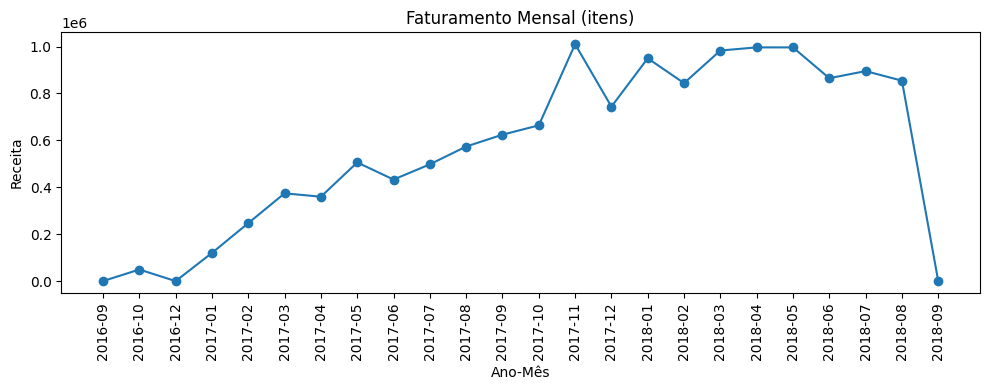

In [ ]:
# Gráfico de faturamento mensal

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
kpi_plot = kpi_mensal.sort_values("ano_mes")
plt.plot(kpi_plot["ano_mes"],
         kpi_plot["revenue_items"],
         marker="o")
plt.xticks(rotation=90)
plt.title("Faturamento Mensal (itens)")
plt.xlabel("Ano-Mês")
plt.ylabel("Receita")
plt.tight_layout()
plt.show()

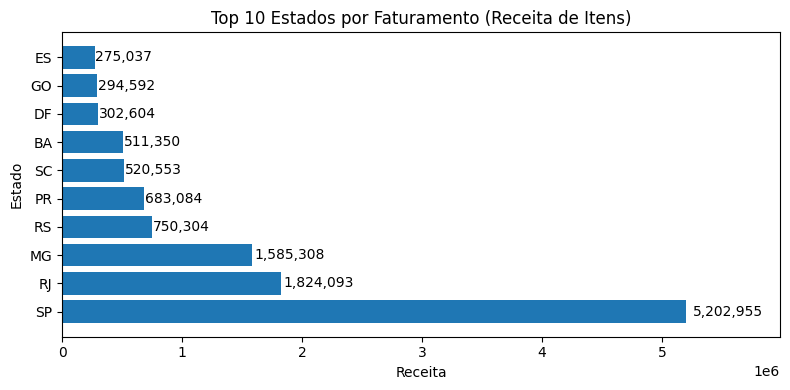

In [ ]:
# Gráfico de barras: top 10 estados

top10_estados = (
    kpi_estado
    .sort_values("revenue_items", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
plt.barh(top10_estados["customer_state"], top10_estados["revenue_items"])
plt.title("Top 10 Estados por Faturamento (Receita de Itens)")
plt.xlabel("Receita")
plt.ylabel("Estado")

max_value = top10_estados["revenue_items"].max()

plt.xlim(0, max_value * 1.15)

for i, v in enumerate(top10_estados["revenue_items"]):
    plt.text(v * 1.01, i, f"{v:,.0f}", va="center")

plt.tight_layout()

plt.show()

In [ ]:
# Kpi por categoria
# Objetivo: entender quais categorias puxam receita

kpi_categoria = (
    df_items
    .groupby("product_category_name_en", as_index=False)
    .agg(
        revenue_items=("price", "sum"),
        orders_count=("order_id", "nunique")
    )
)

kpi_categoria["avg_ticket"] = (
    kpi_categoria["revenue_items"] / kpi_categoria["orders_count"]
).round(2)

kpi_categoria["revenue_share"] = (
    kpi_categoria["revenue_items"] / kpi_categoria["revenue_items"].sum()
).round(4)

# Limpa categorias (para evitar ruído)
kpi_categoria = kpi_categoria[kpi_categoria["orders_count"] >= 10]

kpi_categoria = kpi_categoria.sort_values("revenue_items", ascending=False)

display(kpi_categoria.head(10))

,product_category_name_en,revenue_items,orders_count,avg_ticket,revenue_share
43,health_beauty,1258681.34,8836,142.45,0.0939
70,watches_gifts,1205005.68,5624,214.26,0.0899
7,bed_bath_table,1036988.68,9417,110.12,0.0773
65,sports_leisure,988048.97,7720,127.99,0.0737
15,computers_accessories,911954.32,6689,136.34,0.0680
39,furniture_decor,729762.49,6449,113.16,0.0544
20,cool_stuff,635290.85,3632,174.91,0.0474
49,housewares,632248.66,5884,107.45,0.0472
5,auto,592720.11,3897,152.10,0.0442
42,garden_tools,485256.46,3518,137.94,0.0362


In [ ]:
# Exportar csvs tratados para power bi

OUTPUT_PATH = "/content/drive/MyDrive/olist_tratado"
os.makedirs(OUTPUT_PATH, exist_ok=True)

df_items.to_csv(f"{OUTPUT_PATH}/fato_itens.csv", index=False)
kpi_mensal.to_csv(f"{OUTPUT_PATH}/kpi_mensal.csv", index=False)
kpi_estado.to_csv(f"{OUTPUT_PATH}/kpi_estado.csv", index=False)
kpi_categoria.to_csv(f"{OUTPUT_PATH}/kpi_categoria.csv", index=False)

print("Arquivos exportados para:", OUTPUT_PATH)

Arquivos exportados para: /content/drive/MyDrive/olist_tratado
